In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install plotly

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mpl
import seaborn as sb
import plotly.express as px

In [3]:
data_titanic = pd.read_csv('train.csv')
survived_data = int(data_titanic['Survived'].sum())
pclass_data = data_titanic['Pclass'].value_counts()
age_data = data_titanic['Age'].dropna().values
sex_data = data_titanic['Sex'].value_counts()
parch_data = data_titanic['Parch'].values

<bound method _AxesBase.grid of <Axes: title={'center': "Titanic passengers' Deaths/Survivors"}, xlabel='Status', ylabel='Amount, passengers'>>

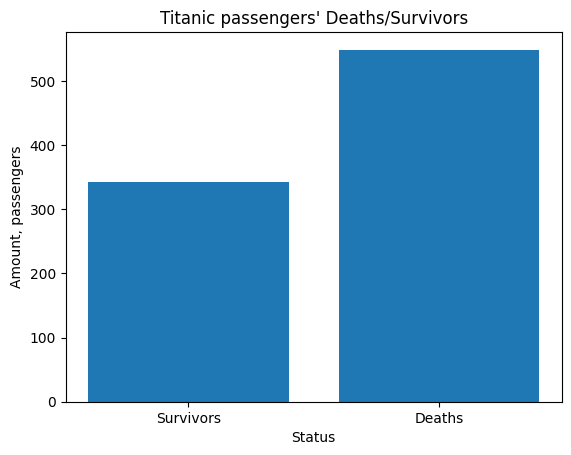

In [4]:
fig_survived, ax_survived = mpl.subplots()
survived_ax_label = ['Survivors', 'Deaths']
survived_ax_data = [survived_data, int(data_titanic['PassengerId'].max()) - survived_data]
ax_survived.bar(x=survived_ax_label, height=survived_ax_data)
ax_survived.set_xlabel('Status')
ax_survived.set_ylabel('Amount, passengers')
ax_survived.set_title("Titanic passengers' Deaths/Survivors")
ax_survived.grid

<bound method _AxesBase.grid of <Axes: title={'center': 'Class distribution'}, xlabel='Class number', ylabel='Amount, passengers'>>

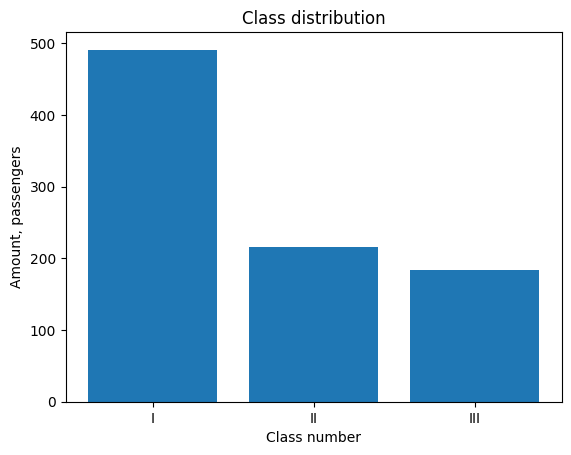

In [5]:
fig_pclass, ax_pclass = mpl.subplots()
pclass_ax_label = ['I', 'II', 'III']
pclass_ax_data = [int(i) for i in pclass_data]
ax_pclass.bar(x=pclass_ax_label, height=pclass_ax_data)
ax_pclass.set_xlabel('Class number')
ax_pclass.set_ylabel('Amount, passengers')
ax_pclass.set_title("Class distribution")
ax_pclass.grid

<bound method _AxesBase.grid of <Axes: title={'center': 'Age distribution'}, xlabel='Age', ylabel='Amount, passengers'>>

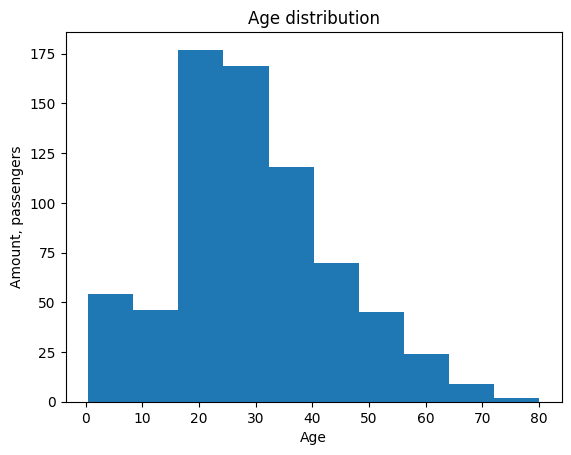

In [6]:
fig_age, ax_age = mpl.subplots()
ax_age.hist(age_data)
ax_age.set_xlabel('Age')
ax_age.set_ylabel('Amount, passengers')
ax_age.set_title("Age distribution")
ax_age.grid

<bound method _AxesBase.grid of <Axes: title={'center': 'Sex distribution'}, xlabel='Sex', ylabel='Amount, passengers'>>

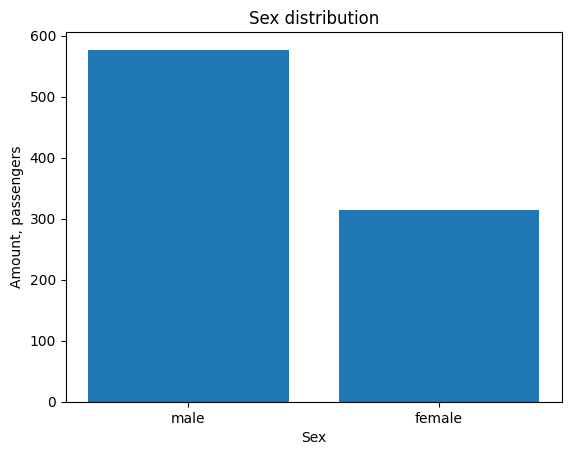

In [7]:
fig_sex, ax_sex = mpl.subplots()
sex_ax_label = [i for i in sex_data.index]
sex_ax_data = [int(i) for i in sex_data]
ax_sex.bar(x=sex_ax_label, height=sex_ax_data)
ax_sex.set_xlabel('Sex')
ax_sex.set_ylabel('Amount, passengers')
ax_sex.set_title("Sex distribution")
ax_sex.grid

<bound method _AxesBase.grid of <Axes: title={'center': 'Parch distribution'}, xlabel='Parch', ylabel='Amount, passengers'>>

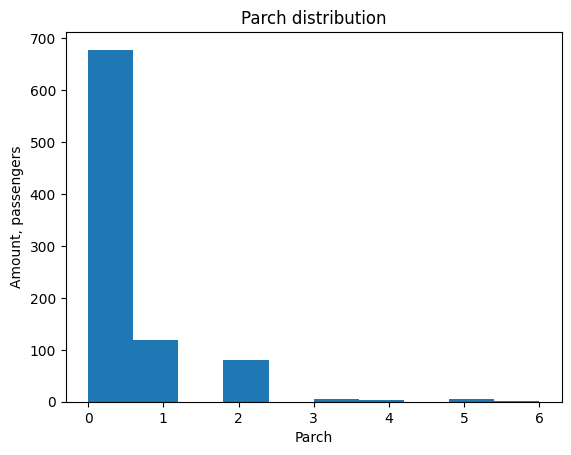

In [8]:
fig_parch, ax_parch = mpl.subplots()
ax_parch.hist(parch_data)
ax_parch.set_xlabel('Parch')
ax_parch.set_ylabel('Amount, passengers')
ax_parch.set_title("Parch distribution")
ax_parch.grid

<Axes: ylabel='Age'>

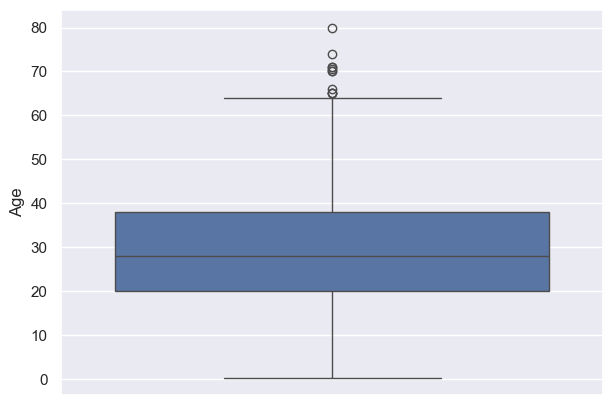

In [9]:
sb.set(rc={'figure.figsize':(7, 5)})
sb.boxplot(y=data_titanic['Age'])

In [10]:
'''
Минимальное и максимальное значения - 0 и 63 (примерно)
Медиана - ок. 29 лет
Выбросы - от 65 до 81 года (примерно)
25 и 75 квартили - 20 и 39 лет соответственно (примерно)
'''

'\nМинимальное и максимальное значения - 0 и 63 (примерно)\nМедиана - ок. 29 лет\nВыбросы - от 65 до 81 года (примерно)\n25 и 75 квартили - 20 и 39 лет соответственно (примерно)\n'

In [11]:
passanger_amount = data_titanic['PassengerId'].max()
pclass_surv = data_titanic.groupby('Pclass')["Survived"].sum().apply(lambda x: x / passanger_amount)

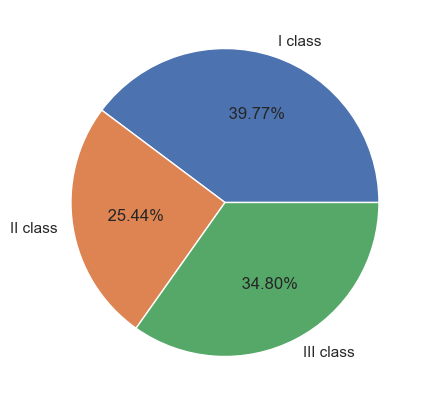

In [12]:
pclass_surv_labels = ['I class', 'II class', 'III class']
pclass_surv_value = [float(i) for i in pclass_surv]
fig_surv_pclass, ax_surv_pclass = mpl.subplots()
ax_surv_pclass.pie(pclass_surv_value, labels=pclass_surv_labels, autopct= ' %1.2f%%');

In [13]:
data_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


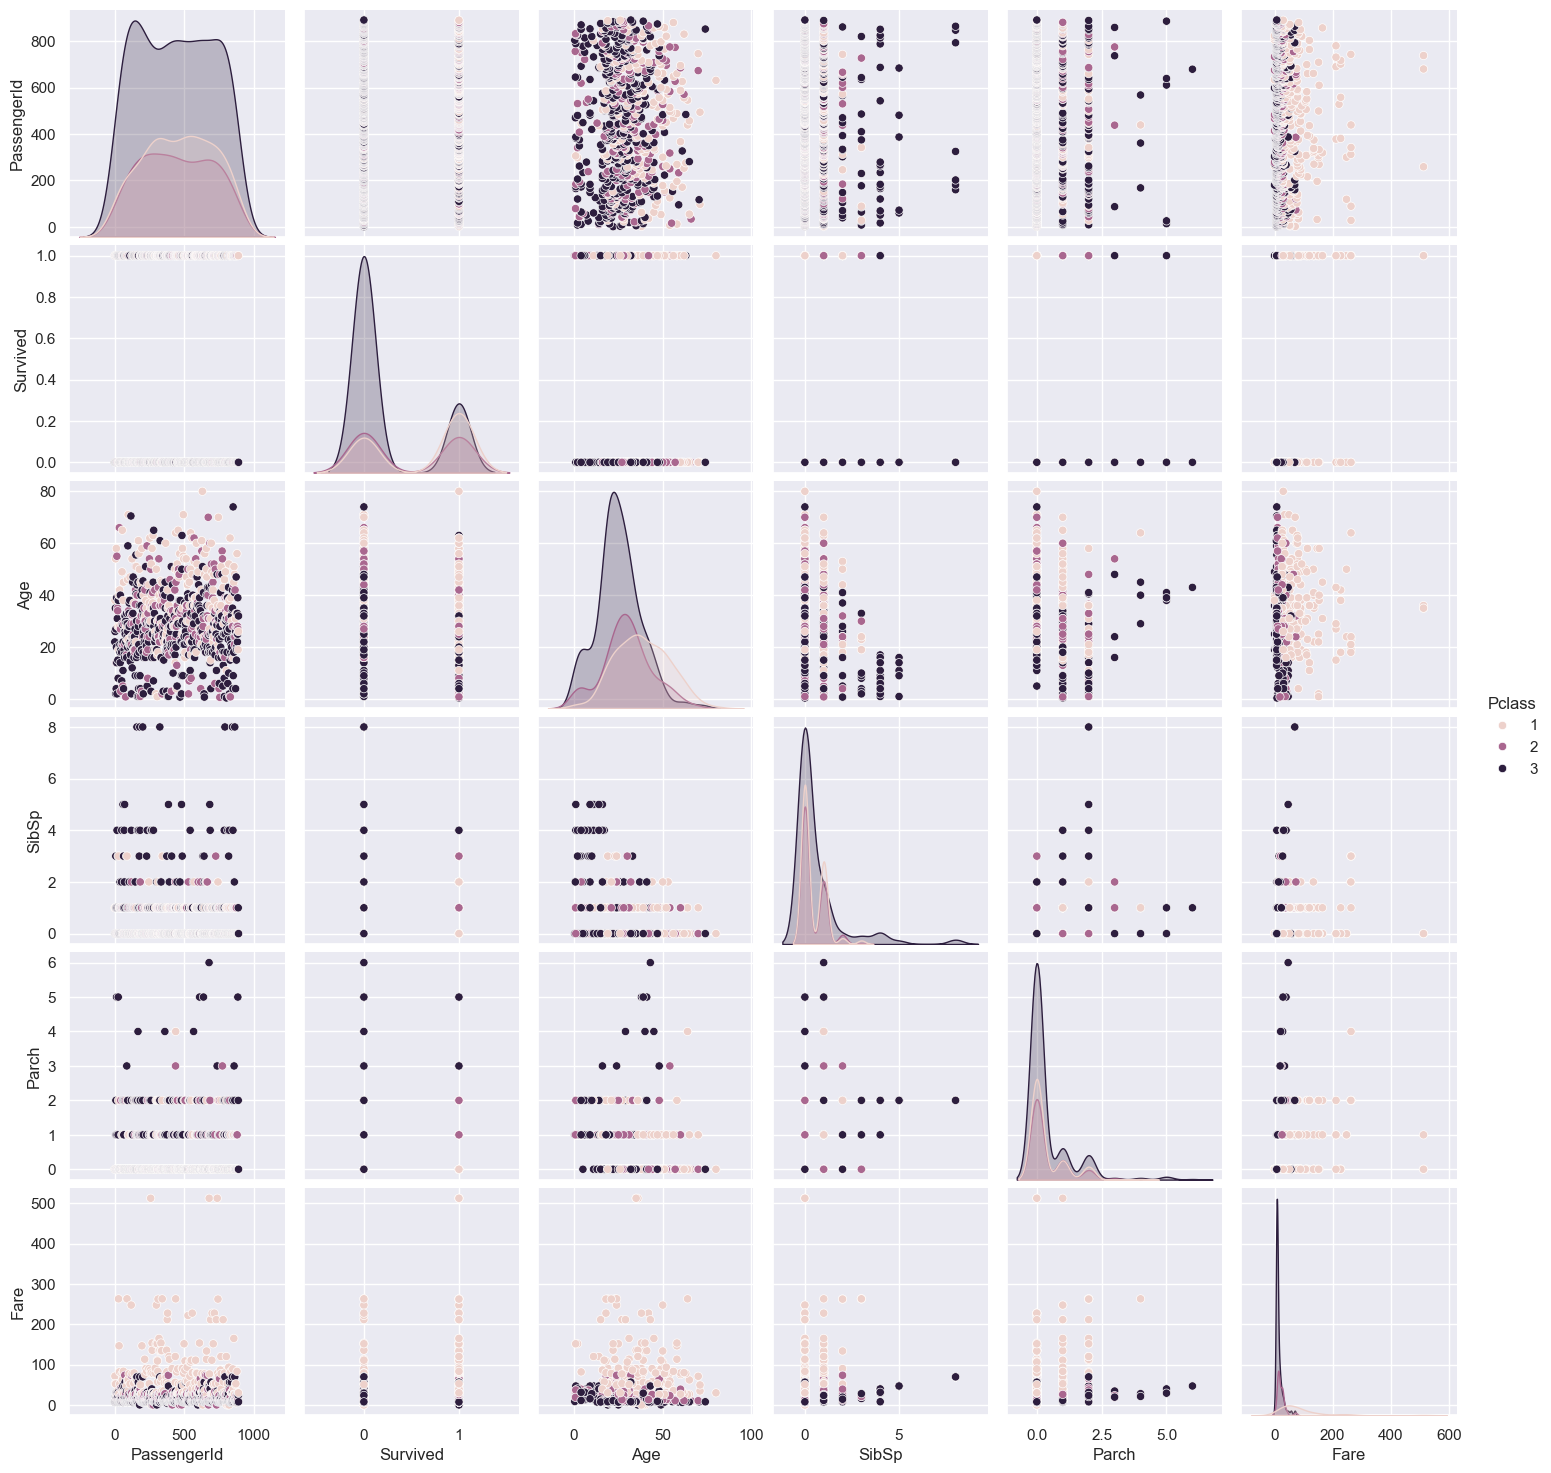

In [14]:
sb.pairplot(data_titanic, hue='Pclass')

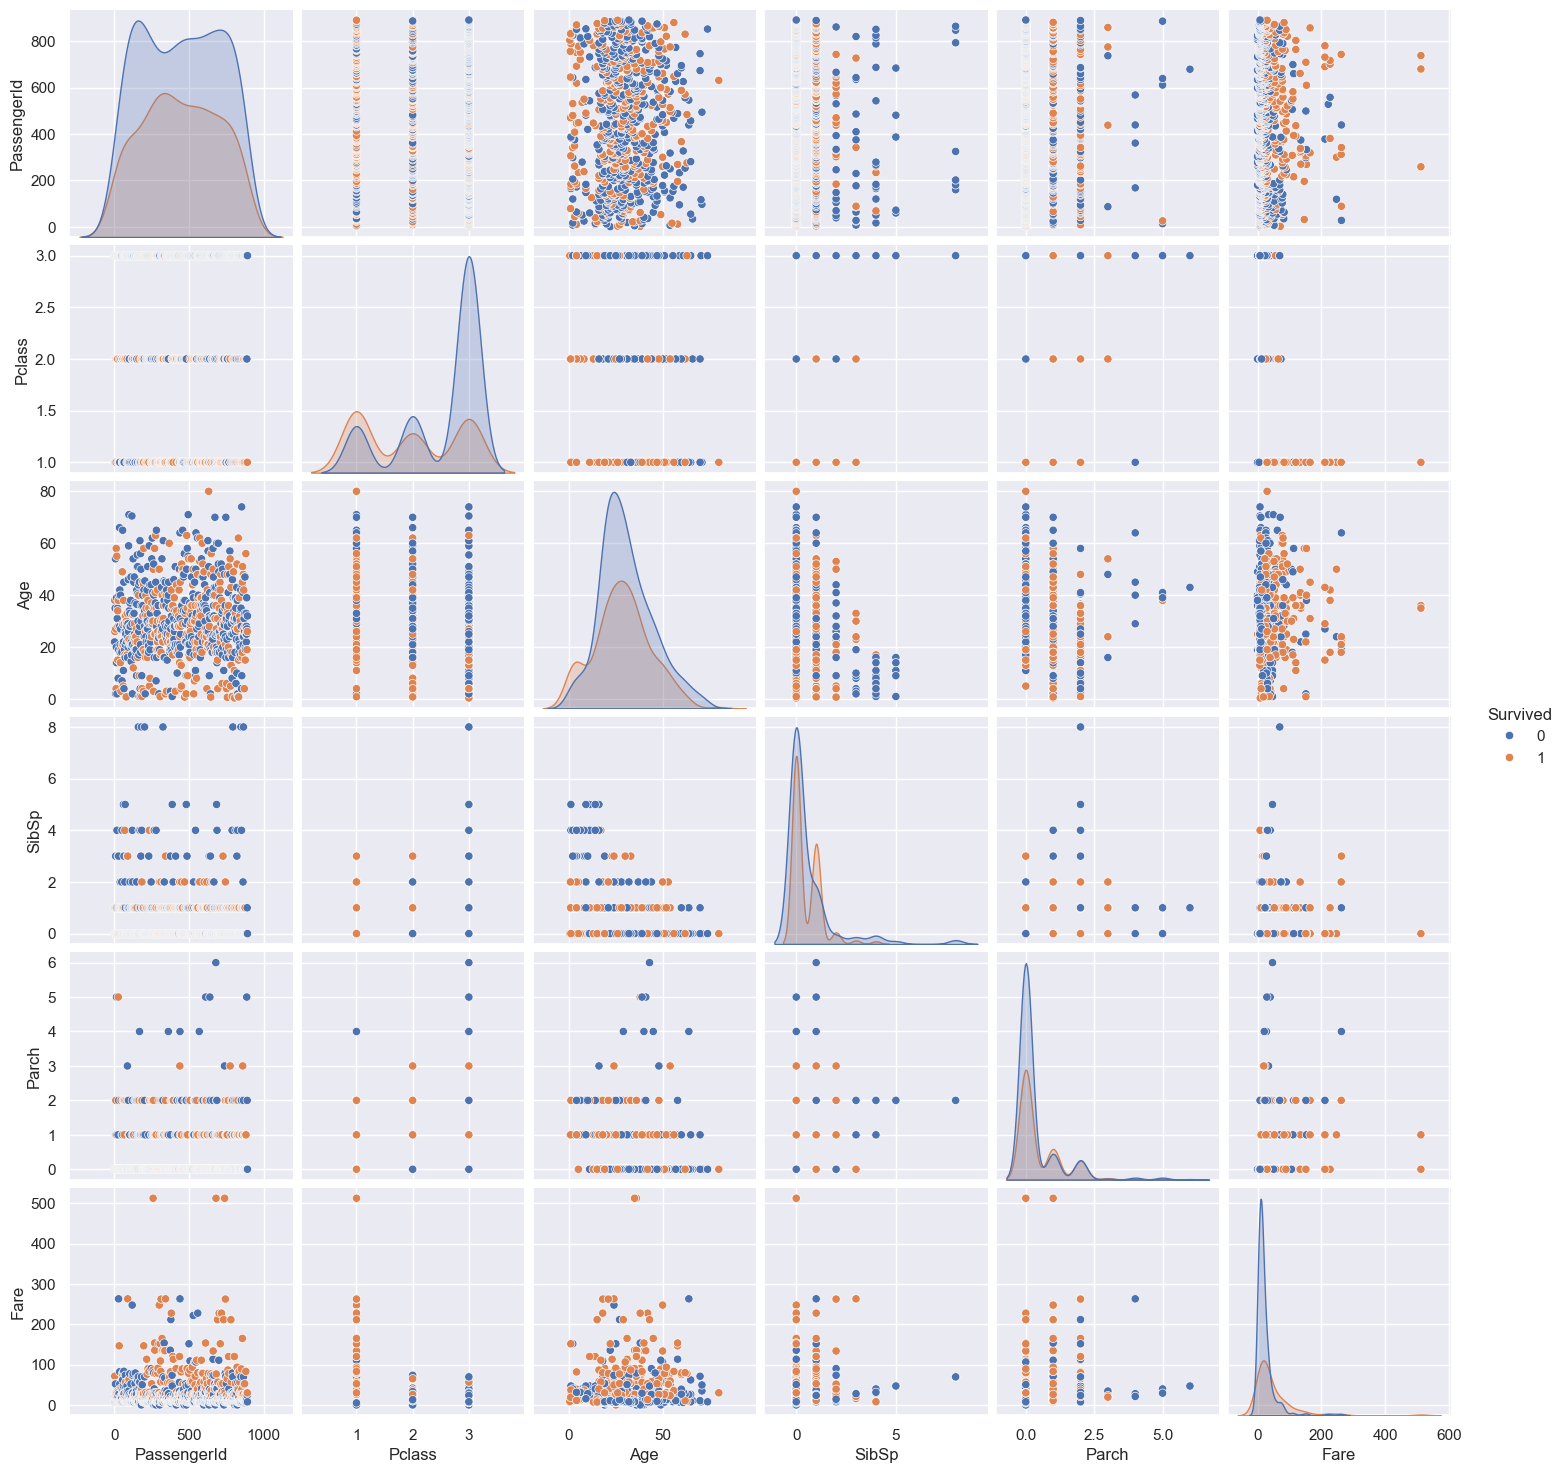

In [15]:
sb.pairplot(data_titanic, hue='Survived')

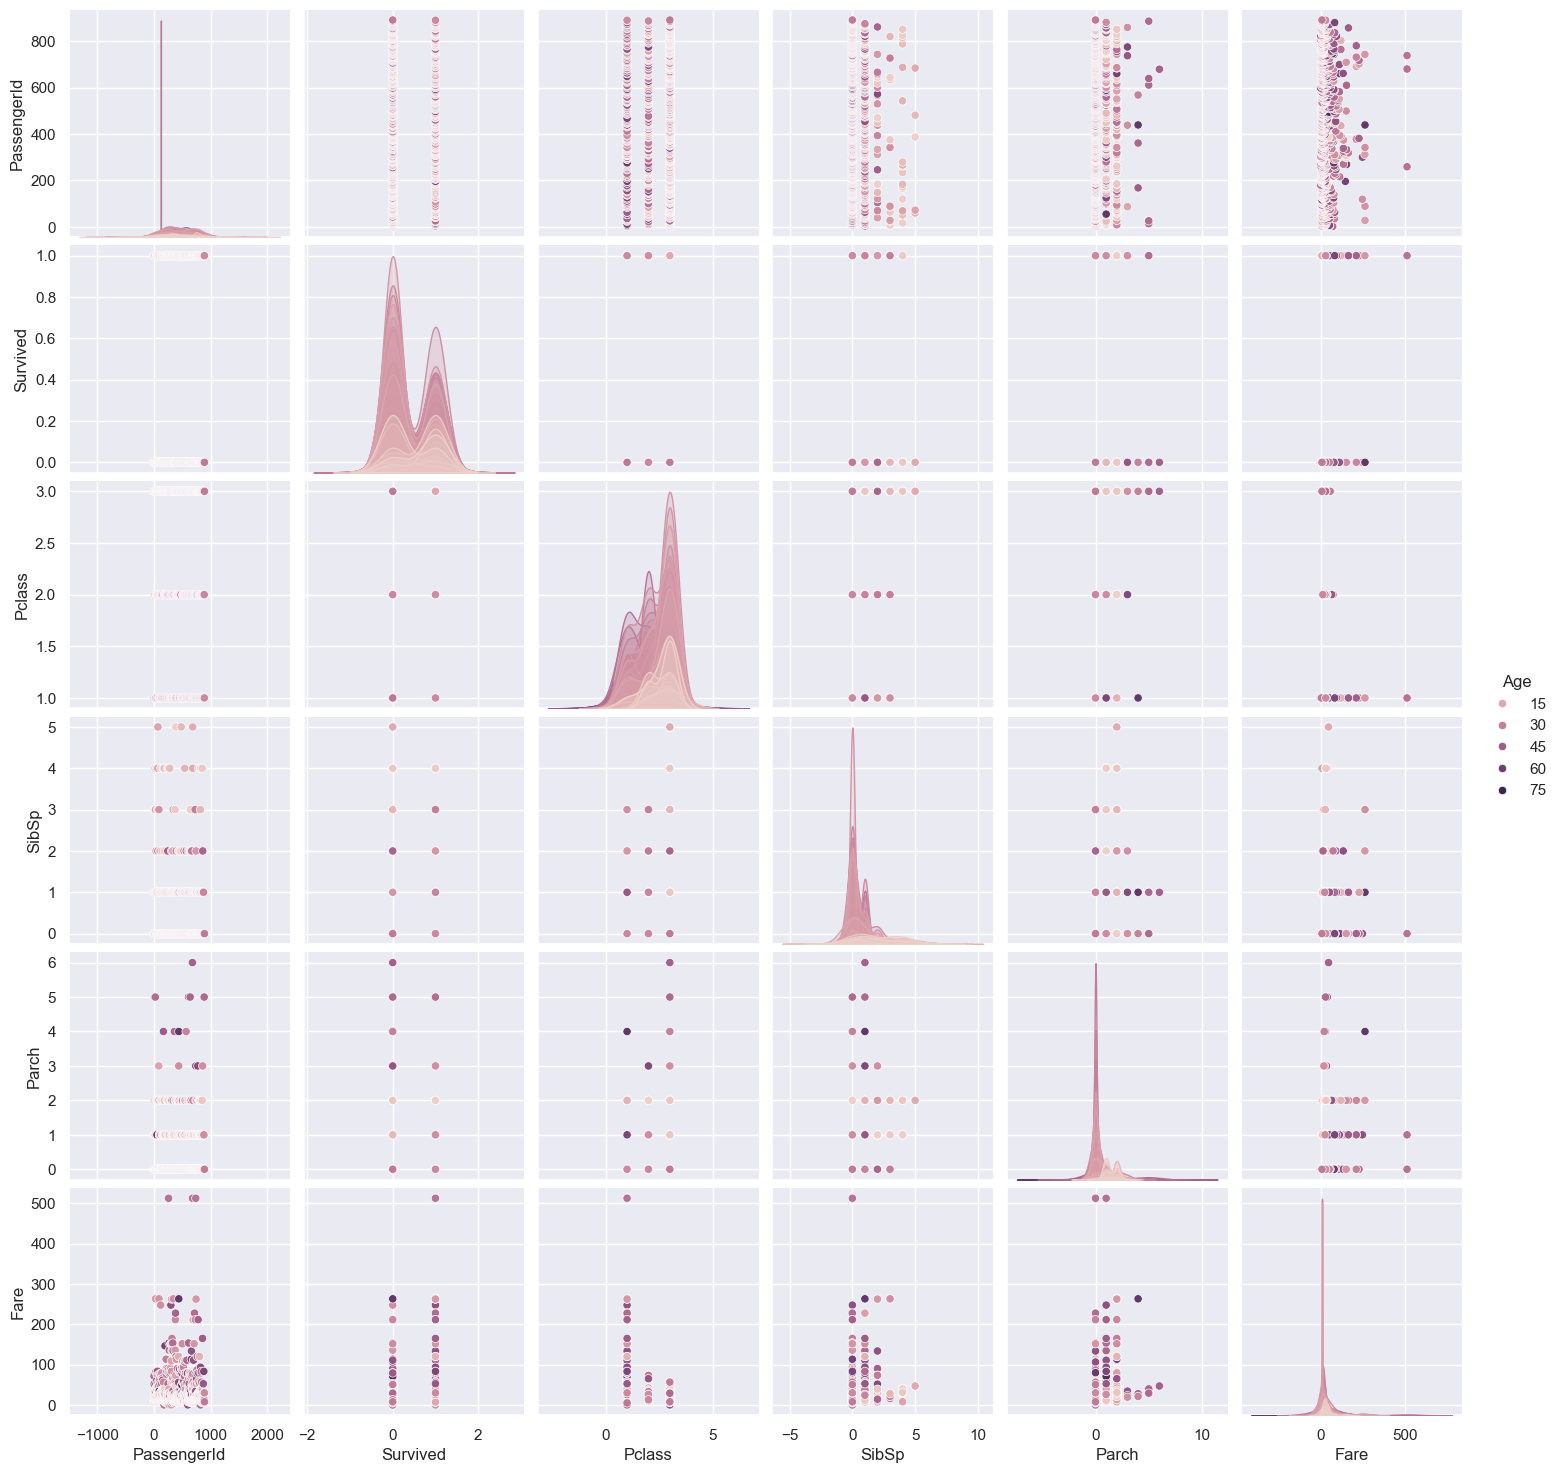

In [16]:
sb.pairplot(data_titanic, hue='Age')

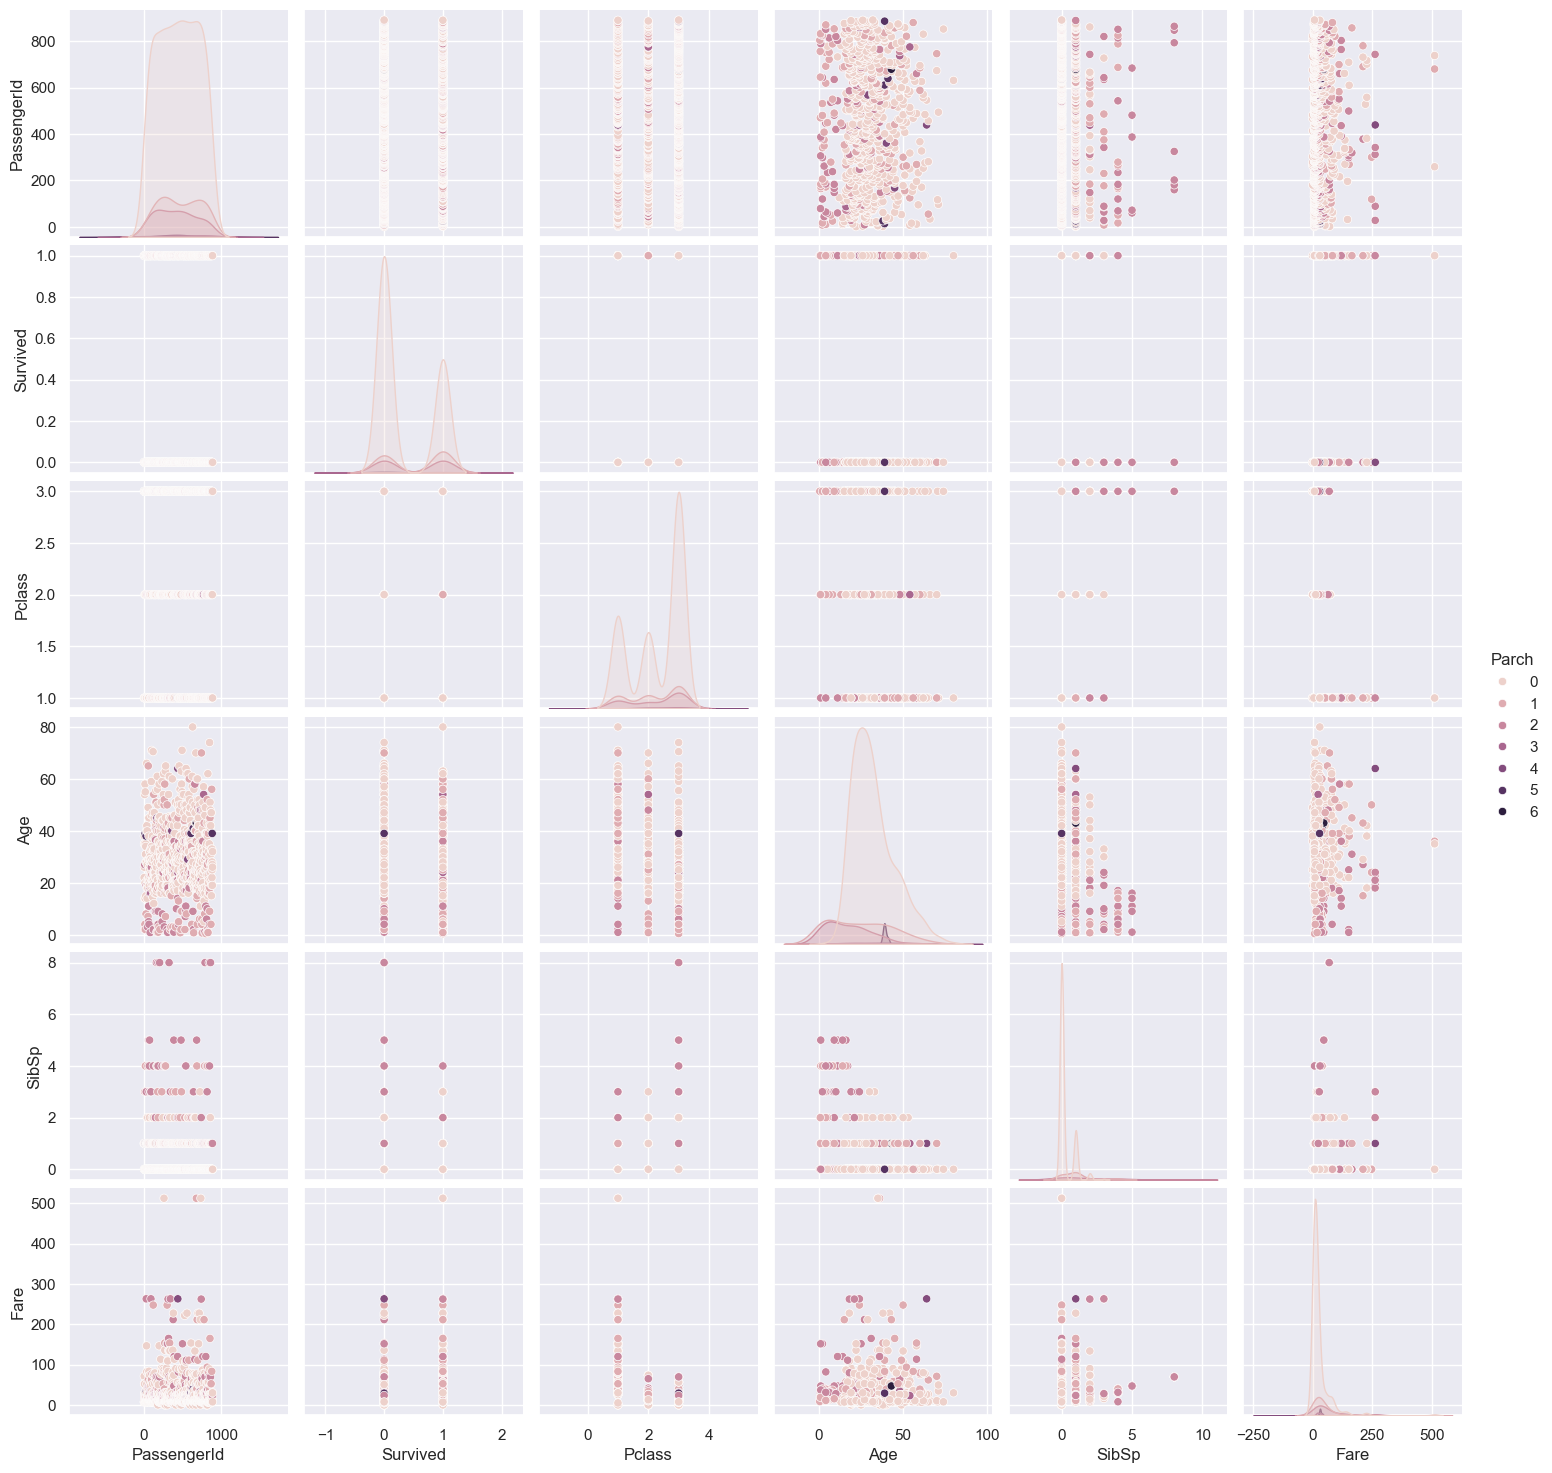

In [17]:
sb.pairplot(data_titanic, hue='Parch')

In [18]:
pass_by_class_sex = data_titanic.groupby('Pclass')['Sex']
sunburst_values = [int(data_titanic['PassengerId'].max())]
for pclass in range(data_titanic['Pclass'].max()):
    sunburst_values.append(int(data_titanic[data_titanic['Pclass'] == pclass + 1].shape[0]))
    for amount in pass_by_class_sex.get_group(pclass + 1).value_counts():
        sunburst_values.append(amount)
sunburst_data = dict(
    categories = ['Total pass', 'I', 'II', 'III',
                  'Male I', 'Female I',
                  'Male II', 'Female II',
                  'Male III', 'Female III'],
    parent = ['', 'Total pass', 'Total pass', 'Total pass', 'I', 'I', 'II', 'II', 'III', 'III'],
    value = sunburst_values
)
sunburst_fig = px.sunburst(sunburst_data, names='categories', values='value', branchvalues='total')
sunburst_fig.show()